
# Unidade 3: Modelos de Séries Temporais  
## Seção 3.2: Decomposição de Séries Temporais (Python)

Este notebook é a conversão do script em R para Python, utilizando principalmente `pandas`, `matplotlib` e `statsmodels`.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose, STL



## Carregamento dos dados

No R, utilizamos `.RData`. Em Python, recomenda-se converter para `.csv`.


In [2]:

# Exemplo: substitua pelo caminho correto
pib = pd.read_csv("pib.csv")

# Estrutura esperada:
# coluna 'Data' e coluna 'PIB'


In [3]:
pib.head()

,Data,PIB
0,2004-01-01,144558.6
1,2004-02-01,142861.3
2,2004-03-01,157363.5
3,2004-04-01,156953.9
4,2004-05-01,159498.9



## Criação da série temporal

Equivalente ao `ts()` do R.


In [4]:

# Converter coluna de data
pib['Data'] = pd.to_datetime(pib['Data'], format='%Y-%m-%d')
pib = pib.set_index('Data')

# Definir frequência mensal
y = pib['PIB'].asfreq('MS')



## Visualização da série temporal


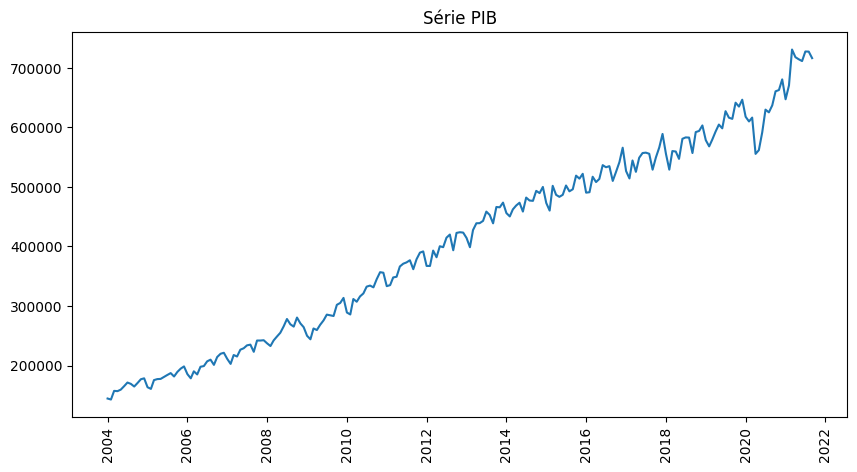

In [6]:

plt.figure(figsize=(10,5))
plt.plot(y)
plt.title("Série PIB")
plt.xticks(rotation=90)
plt.show()



## Decomposição Aditiva


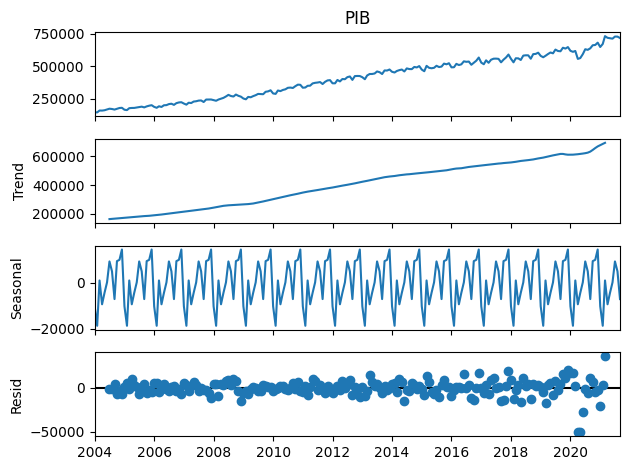

In [7]:

decomp = seasonal_decompose(y, model='additive', period=12)

decomp.plot()
plt.show()



## Extração dos componentes


In [8]:

trend = decomp.trend
seasonal = decomp.seasonal
resid = decomp.resid



## Construção de DataFrame com componentes


In [9]:

df = pd.DataFrame({
    'serie': y,
    'tendencia': trend,
    'sazonalidade': seasonal,
    'erro': resid
})

df['dessazonalizada'] = df['serie'] - df['sazonalidade']
df = df.dropna()



## Plot conjunto dos componentes


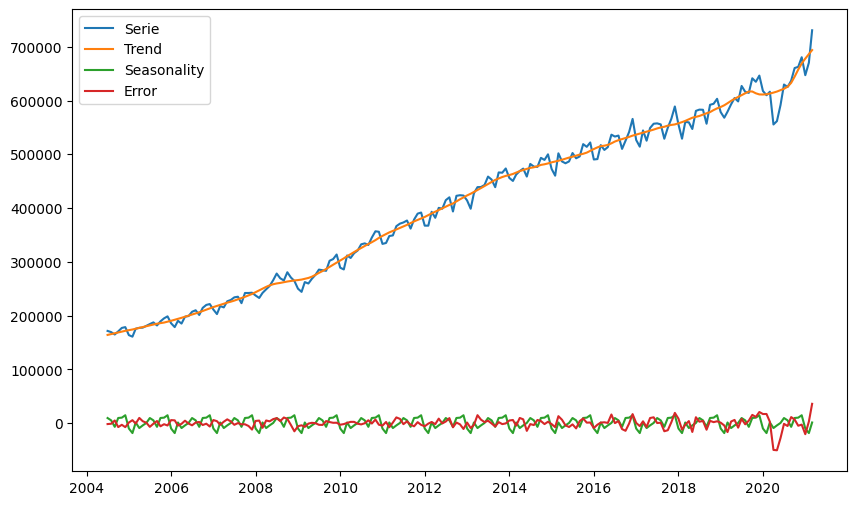

In [10]:

plt.figure(figsize=(10,6))
plt.plot(df['serie'], label='Serie')
plt.plot(df['tendencia'], label='Trend')
plt.plot(df['sazonalidade'], label='Seasonality')
plt.plot(df['erro'], label='Error')
plt.legend()
plt.show()



## Subplots dos componentes


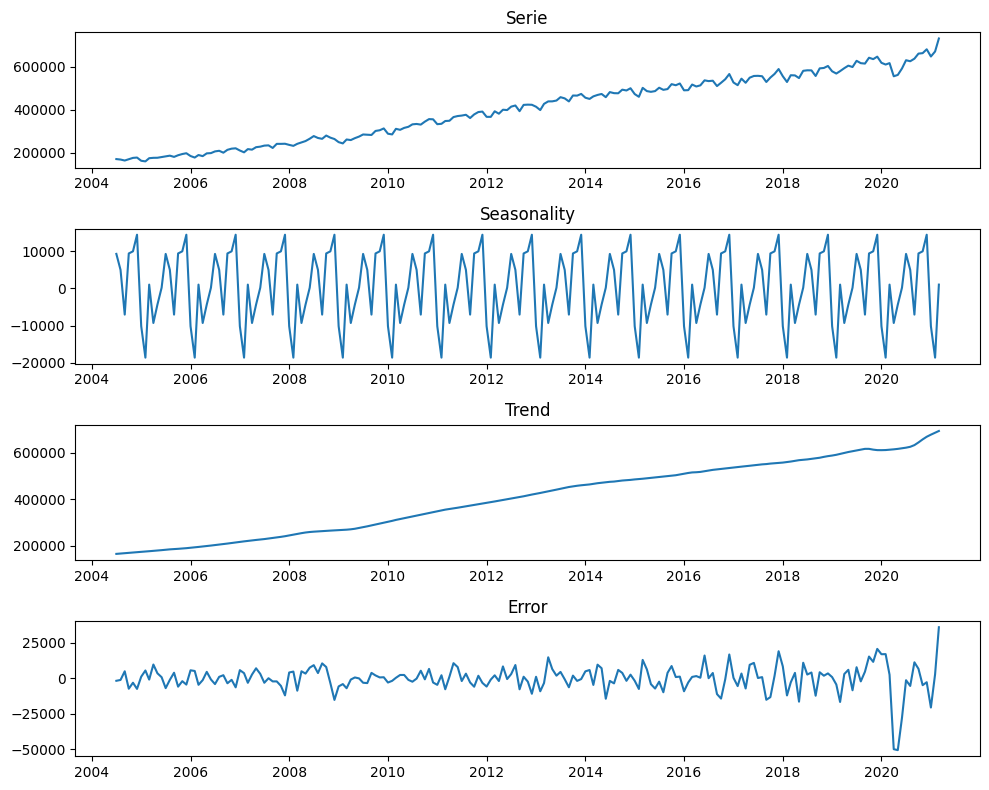

In [11]:

fig, axs = plt.subplots(4, 1, figsize=(10,8))

axs[0].plot(df['serie'])
axs[0].set_title('Serie')

axs[1].plot(df['sazonalidade'])
axs[1].set_title('Seasonality')

axs[2].plot(df['tendencia'])
axs[2].set_title('Trend')

axs[3].plot(df['erro'])
axs[3].set_title('Error')

plt.tight_layout()
plt.show()



## Série original vs dessazonalizada


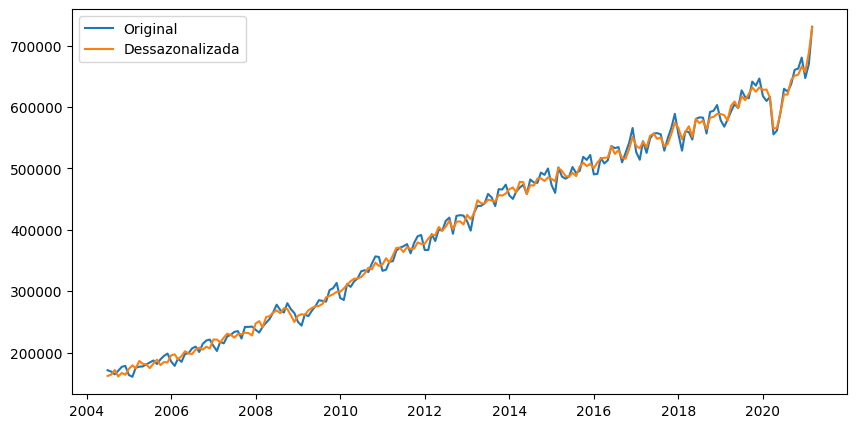

In [12]:

plt.figure(figsize=(10,5))
plt.plot(df['serie'], label='Original')
plt.plot(df['dessazonalizada'], label='Dessazonalizada')
plt.legend()
plt.show()



## Decomposição Multiplicativa


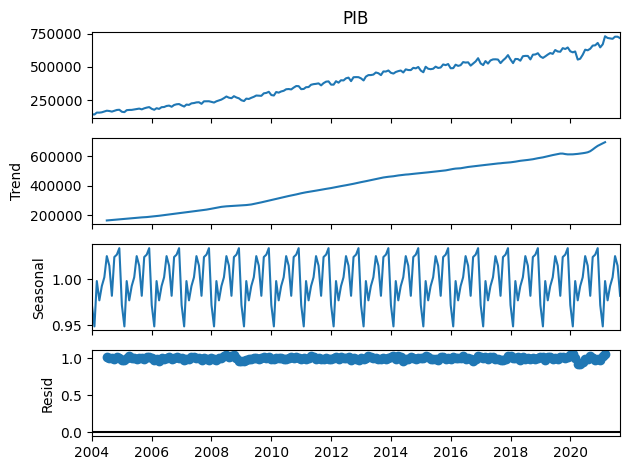

In [13]:

decomp_mult = seasonal_decompose(y, model='multiplicative', period=12)
decomp_mult.plot()
plt.show()



## Alternativa Moderna: STL

Mais robusta que a decomposição clássica.


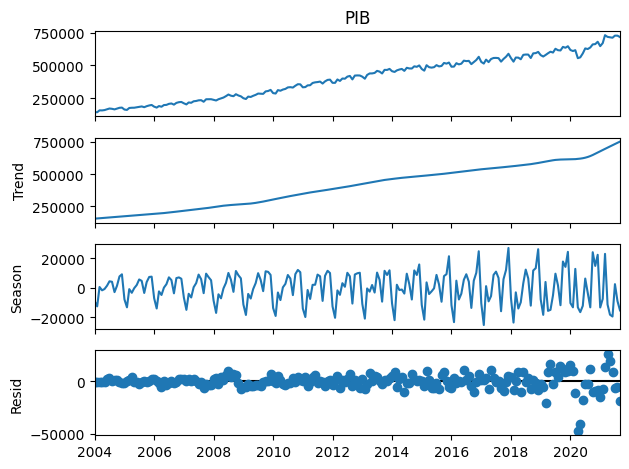

In [14]:

stl = STL(y, period=12)
res = stl.fit()
res.plot()
plt.show()
